In [1]:
!pip install pyod torch pandas numpy scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.8/219.8 kB 10.4 MB/s eta 0:00:00


In [3]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [6]:
!pip install pyod==1.1.0 torch pandas numpy scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.4/153.4 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyod: filename=pyod-1.1.0-py3-none-any.whl size=185321 sha256=452ce03d4770cfda5db6dd99650953f01ba286b39de5019a0f8762802c9cb2e8
  Stored in directory: /root/.cache/pip/wheels/c8/25/33/e080d421c5aa885c49a22af235cbdf50f08e51932bb9a7449a
Successfully built pyod
  Attempting uninstall: pyod
    Found existing installation: pyod 2.0.7
    Uninstalling pyod-2.0.7:
      Successfully uninstalled pyod-2.0.7


Loading dataset...
Dataset shape: (284807, 31)
Preprocessing data...
Building AutoEncoder model...
Training model...


Training: 100%|██████████| 10/10 [05:16<00:00, 31.67s/it]


Predicting anomalies...

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    284315
           1       0.07      0.78      0.12       492

    accuracy                           0.98    284807
   macro avg       0.53      0.88      0.56    284807
weighted avg       1.00      0.98      0.99    284807


=== Confusion Matrix ===
[[279002   5313]
 [   108    384]]


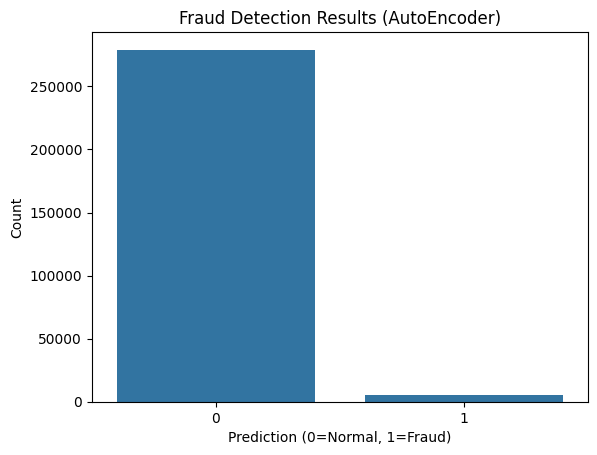

In [8]:
# ===========================
# IMPORTS
# ===========================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from pyod.models.auto_encoder import AutoEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# LOAD DATA
# ===========================
def load_data(file_path):
    print("Loading dataset...")
    df = pd.read_csv(file_path)
    print("Dataset shape:", df.shape)
    return df

# ===========================
# PREPROCESS DATA
# ===========================
def preprocess_data(df):
    print("Preprocessing data...")

    X = df.drop('Class', axis=1)
    y = df['Class']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y

# ===========================
# BUILD MODEL
# ===========================
def build_model():
    print("Building AutoEncoder model...")

    # minimal args → works across all PyOD versions
    model = AutoEncoder(contamination=0.02)

    return model

# ===========================
# TRAIN MODEL
# ===========================
def train_model(model, X):
    print("Training model...")
    model.fit(X)
    return model

# ===========================
# PREDICT
# ===========================
def predict(model, X):
    print("Predicting anomalies...")

    y_pred = model.predict(X)
    scores = model.decision_function(X)

    return y_pred, scores

# ===========================
# EVALUATION
# ===========================
def evaluate(y_true, y_pred):
    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred))

    print("\n=== Confusion Matrix ===")
    print(confusion_matrix(y_true, y_pred))

# ===========================
# VISUALIZATION
# ===========================
def visualize(y_pred):
    plt.figure()
    sns.countplot(x=y_pred)
    plt.title("Fraud Detection Results (AutoEncoder)")
    plt.xlabel("Prediction (0=Normal, 1=Fraud)")
    plt.ylabel("Count")
    plt.show()

# ===========================
# MAIN PIPELINE
# ===========================
def main():
    df = load_data('creditcard.csv')

    X, y = preprocess_data(df)

    model = build_model()

    model = train_model(model, X)

    y_pred, scores = predict(model, X)

    evaluate(y, y_pred)

    visualize(y_pred)

# ===========================
# RUN
# ===========================
if __name__ == "__main__":
    main()